# Análisis Exploratorio de Datos (EDA)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

# Cargar el Dataset
df = pd.read_csv('data/retailmax.csv')

# 1. ¿Cuál es la distribución de edades de los clientes?

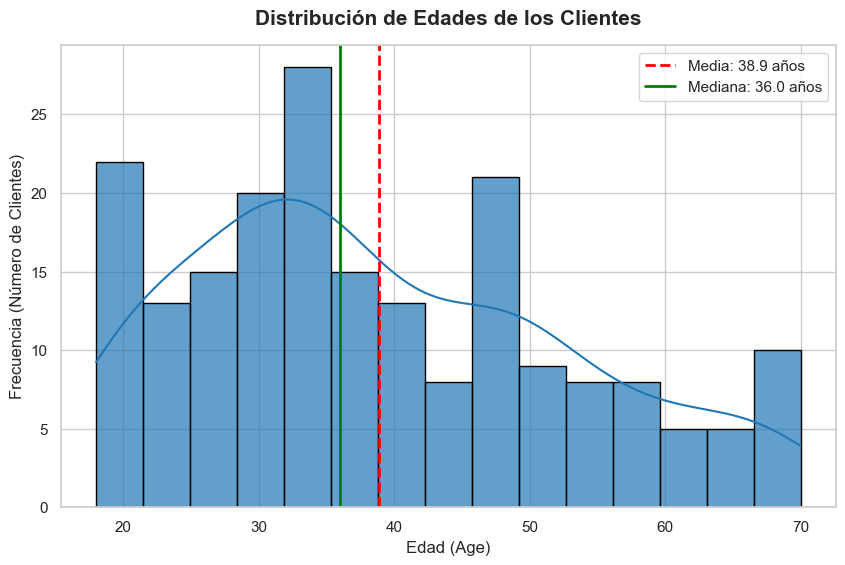

In [ ]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=15, kde=True, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades de los Clientes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f} años')
plt.axvline(df['Age'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["Age"].median():.1f} años')
plt.legend(fontsize=11)
plt.show()

# 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

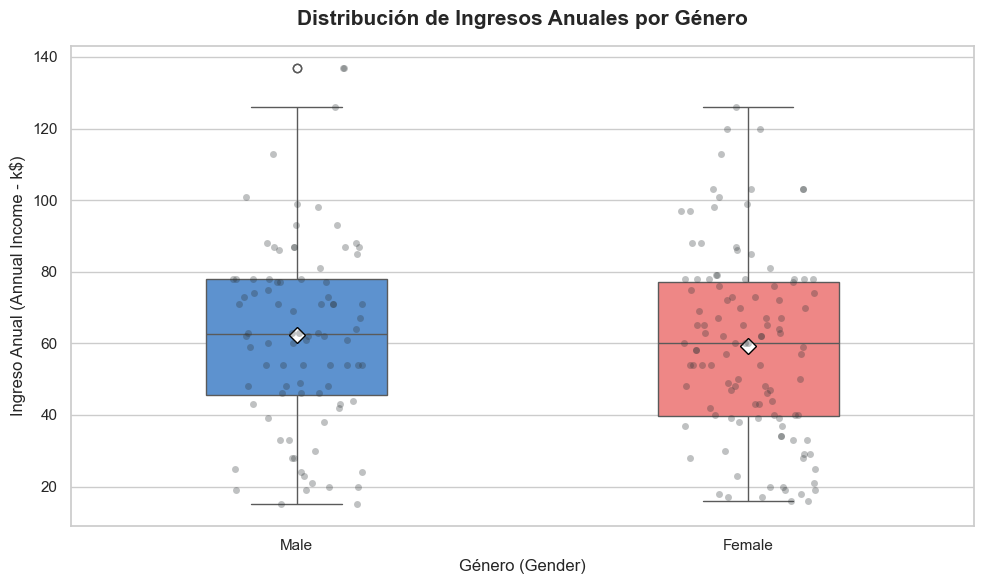

In [ ]:
plt.figure(figsize=(10, 6))

# Gráfico de caja (boxplot) con strip plot superpuesto para ver la distribución individual
sns.boxplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    width=0.4,
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Mostrar los puntos individuales de datos de manera sutil
sns.stripplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    color='#2d3436', 
    alpha=0.3, 
    jitter=0.15, 
    size=5
)

plt.title('Distribución de Ingresos Anuales por Género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género (Gender)', fontsize=12)
plt.ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de ingresos anuales entre hombres y mujeres, observamos que **no existen diferencias drásticas**, aunque sí se aprecian ligeras variaciones a favor del grupo masculino:

1. **Promedio (Media) y Mediana:**
   - Los **hombres** tienen un ingreso anual promedio de **62.23 k$** y una mediana de **62.50 k$**.
   - Las **mujeres** tienen un ingreso anual promedio de **59.25 k$** y una mediana de **60.00 k$**.
   - Esto representa una ligera diferencia de **~2.98 k$ en la media** y **2.50 k$ en la mediana** a favor de los hombres.

2. **Dispersión y Límites:**
   - La dispersión (desviación estándar) es sumamente similar en ambos grupos: **26.64 k$** para hombres y **26.01 k$** para mujeres.
   - Los rangos intercuartílicos y las cajas en el gráfico muestran que el 50% central de la población se encuentra en rangos muy similares, aunque el límite inferior del 25% de los hombres (45.5 k$) es ligeramente mayor al de las mujeres (39.75 k$).
   - El ingreso máximo registrado pertenece a un hombre con **137 k$**, mientras que el de las mujeres es de **126 k$**.

**Conclusión:** Aunque estadísticamente los hombres muestran ingresos ligeramente superiores en términos de medidas de tendencia central (media y mediana) y valores máximos, las distribuciones se superponen en gran medida. Esto sugiere que **el género no es un factor determinante o altamente diferenciador** para el nivel de ingresos en este conjunto de datos.

# 3. ¿Cómo se distribuye la puntuación de gastos entre los diferentes rangos de edades?

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    hue='Gender',
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    alpha=0.8,
    s=80
)

plt.title('Relación entre la Edad y la Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score 1-100)', fontsize=12)
plt.tight_layout()
plt.show()

# Análisis del Comportamiento: Edad vs. Score de Gasto

Al cruzar la edad (`Age`) con el nivel de consumo (`Spending Score`), los datos no muestran una pendiente lineal, sino una **ruptura estructural** drástica al llegar a una edad específica. El comportamiento se divide en dos universos completamente diferentes.

---

### 🧠 El "Techo de Gasto" a los 40 Años

El hallazgo más contundente del set de datos es la existencia de una barrera generacional infranqueable:

> ⚠️ **Umbral Crítico:** Al cruzar la frontera de los **40 años**, el potencial de registrar un score de gasto alto desaparece por completo. Prácticamente el 100% de los clientes senior se estabilizan en la franja baja-moderada.

* **Techo operativo:** Ningún cliente mayor de 40 años logra superar los **60 puntos** de score.
* **Zona de confort:** Este segmento se compacta fuertemente en un comportamiento homogéneo, manteniendo una media de gasto de apenas **~33 puntos**.

---

### ⚡ La Bimodalidad del Segmento Joven (< 40 años)

A diferencia de la estabilidad del grupo anterior, el sector de 18 a 40 años es el verdadero motor de alta facturación, aunque se comporta de forma bimodal (se divide en dos extremos):

* **Los "High-Spenders":** Este es el único nicho capaz de romper el techo de los 60 puntos, extendiéndose de forma masiva hasta los **99 puntos** de score.
* **El Grupo Polarizado:** Los jóvenes no tienen un comportamiento medio; o se concentran en una fuerte cultura de ahorro/gasto mínimo, o se disparan al consumo más alto de la muestra.

---

### 🎯 Conclusión Estratégica

```
[Segmento < 40 años]  ➔ Alta dispersión (Target de alto valor / Oportunidad de conversión)
[Segmento ≥ 40 años]  ➔ Comportamiento plano (Consumo predecible / Moderado)
```

La edad no es solo una variable demográfica aquí, es el **principal factor de segmentación**. Mientras que el grupo de más de 40 años requiere una estrategia de retención basada en la predictibilidad (gasto moderado y homogéneo), el grupo joven representa el terreno donde las campañas de alto impacto y productos *premium* tienen viabilidad estadística de éxito.